# Feature Engineering

**Student:** Prithvi Adipudi
**Date:** July 14, 2026


---

## 1. Introduction

A used-car marketplace wants to answer one question the moment a seller types in a
spec sheet: **what is a fair price for this car?** The 1985 Automobile dataset gives us
205 cars described by 25 attributes — dimensions, engine specs, fuel economy, brand —
plus the price we want to predict. That makes this a **regression** problem, and it makes
every section of this report one step toward pricing a car accurately.

The plan:

1. **Explore** the data with descriptive statistics: histograms, box plots, an outlier
   investigation, and a correlation analysis.
2. **Engineer three new features** — a power-to-weight ratio, a stroke-to-bore ratio, and
   a target-encoded brand-prestige score — and state, *before training anything*, what each
   one should do to model performance.
3. **Train baseline models** on the original features, then the same models on the
   original **plus** engineered features, and compare with cross-validated R², RMSE, and MAE.
4. **Apply three families of feature selection** — filter, wrapper, and embedded — and
   check whether the engineered features survive the cut.
5. **Compare inferred predictions** on a held-out test set before and after selection,
   and analyze the results.

Every random operation is seeded, so every number and plot in this report reproduces
exactly on a fresh run.

## 2. Imports

The cell below installs anything missing, imports the stack, and fixes a global random
seed. Section 10 describes each library and function in detail; here they only need to
load.

In [1]:
import subprocess, sys, os, glob, io, contextlib

def ensure(pkg, import_name=None):
    try:
        __import__(import_name or pkg); return
    except ImportError:
        pass
    for extra in ([], ['--break-system-packages']):
        try:
            with contextlib.redirect_stdout(io.StringIO()), contextlib.redirect_stderr(io.StringIO()):
                subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'] + extra,
                                      stdout=subprocess.DEVNULL, stderr=subprocess.DEVNULL)
            return
        except subprocess.CalledProcessError:
            continue

for pkg, name in [('scikit-learn', 'sklearn'), ('seaborn', None)]:
    ensure(pkg, name)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_validate, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LassoCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, mutual_info_regression, RFECV
from sklearn.inspection import permutation_importance
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from IPython.display import Markdown, display

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
BLUE, GREEN, GOLD, RED = '#4C72B0', '#55A868', '#CCA43B', '#C44E52'

print('Libraries loaded. scikit-learn', __import__('sklearn').__version__)

Libraries loaded. scikit-learn 1.8.0


## 3. Loading the Automobile Dataset

The loader below looks for the CSV next to this notebook, then in the working directory,
Downloads, and Desktop, so the notebook runs on any machine without editing a path. If
the file is nowhere local, it falls back to downloading through kagglehub.

<details>
<summary><strong>About this dataset</strong></summary>

The data comes from the 1985 Ward's Automotive Yearbook and is hosted on Kaggle as the
"Automobile Dataset" (originally from the UCI Machine Learning Repository). Each row is
one car. The columns mix three kinds of information: physical dimensions (wheel-base,
length, curb-weight), engine specifications (engine-size, bore, stroke, horsepower), and
market attributes (make, body-style, price). Missing values are stored as the literal
character ?, which is why cleaning comes before any statistics.
</details>

In [2]:
FILENAME_PATTERNS = ['Automobile_data*.csv', 'automobile*.csv', 'Automobile*.csv']

def search_dirs():
    try:
        here = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        here = os.getcwd()
    home = os.path.expanduser('~')
    return [here, os.getcwd(), os.path.join(home, 'Downloads'), os.path.join(home, 'Desktop')]

def find_local_csv():
    for d in search_dirs():
        for pat in FILENAME_PATTERNS:
            hits = glob.glob(os.path.join(d, pat))
            if hits:
                return hits[0]
    return None

path = find_local_csv()
if path:
    df_raw = pd.read_csv(path)
    print(f'Loaded local file: {path}')
else:
    ensure('kagglehub')
    import kagglehub
    folder = kagglehub.dataset_download('toramky/automobile-dataset')
    path = glob.glob(os.path.join(folder, '*.csv'))[0]
    df_raw = pd.read_csv(path)
    print(f'Downloaded via kagglehub: {path}')

print(f'Shape: {df_raw.shape[0]} cars x {df_raw.shape[1]} columns')
df_raw.head()

Loaded local file: /Users/prithviadipudi/Downloads/Automobile_data.csv
Shape: 205 cars x 26 columns


,symboling,normalized-losses,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
0,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495
1,3,?,alfa-romero,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500
2,1,?,alfa-romero,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500
3,2,164,audi,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.4,10.0,102,5500,24,30,13950
4,2,164,audi,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.4,8.0,115,5500,18,22,17450


## 4. Cleaning

Three problems stand between the raw file and any statistics, and each gets a one-line fix:

1. **Missing values are the text ? **, which forces numeric columns like price and
   horsepower to load as text. Fix: replace ? with NaN and convert those columns
   to numbers.
2. **Two columns store numbers as words** (num-of-doors = "four", num-of-cylinders =
   "six"). Fix: map the words to integers so the models can use them as quantities.
3. **Four cars have no price.** Price is the target — a row without a target teaches the
   model nothing — so those four rows are dropped. Every remaining gap is filled with the
   column **median**.

<details>
<summary><strong>Why the median and not the mean?</strong></summary>

Several columns here are right-skewed (Section 5 shows this for price and horsepower).
The mean of a skewed column is dragged toward the long tail, so imputing with it would
fill gaps with an untypical value. The median is the middle car regardless of how extreme
the tail is, which makes it the safer default. normalized-losses is the
column that matters most for this choice — it is missing for 41 of 205 cars, so whatever
fills it appears in a fifth of the data.
</details>

In [3]:
df = df_raw.replace('?', np.nan).copy()

numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm', 'price']
for col in numeric_cols:
    df[col] = pd.to_numeric(df[col])

word_to_num = {'two': 2, 'three': 3, 'four': 4, 'five': 5, 'six': 6, 'eight': 8, 'twelve': 12}
df['num-of-doors'] = df['num-of-doors'].map(word_to_num)
df['num-of-cylinders'] = df['num-of-cylinders'].map(word_to_num)

n_before = len(df)
df = df.dropna(subset=['price']).reset_index(drop=True)
print(f'Dropped {n_before - len(df)} cars with no price -> {len(df)} cars remain')

num_features = df.select_dtypes(include=[np.number]).columns
filled = df[num_features].isna().sum()
df[num_features] = df[num_features].fillna(df[num_features].median())
print('Gaps filled with the median:')
print(filled[filled > 0].to_string())
print(f'\nRemaining missing values anywhere: {df.isna().sum().sum()}')

Dropped 4 cars with no price -> 201 cars remain
Gaps filled with the median:
normalized-losses    37
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2

Remaining missing values anywhere: 0


## 5. Descriptive Statistics

Before engineering anything, this section answers four questions in order: what do the
distributions look like (histograms), how does price vary across categories (box plots),
which cars are extreme and are they errors (outliers), and which columns actually move
with price (correlation).

### 5.1 Histograms

,mean,50%,std,min,max
symboling,0.8,1.0,1.3,-2.0,3.0
normalized-losses,120.7,115.0,32.1,65.0,256.0
num-of-doors,3.1,4.0,1.0,2.0,4.0
wheel-base,98.8,97.0,6.1,86.6,120.9
length,174.2,173.2,12.3,141.1,208.1
width,65.9,65.5,2.1,60.3,72.0
height,53.8,54.1,2.4,47.8,59.8
curb-weight,2555.7,2414.0,517.3,1488.0,4066.0
num-of-cylinders,4.4,4.0,1.1,2.0,12.0
engine-size,126.9,120.0,41.5,61.0,326.0


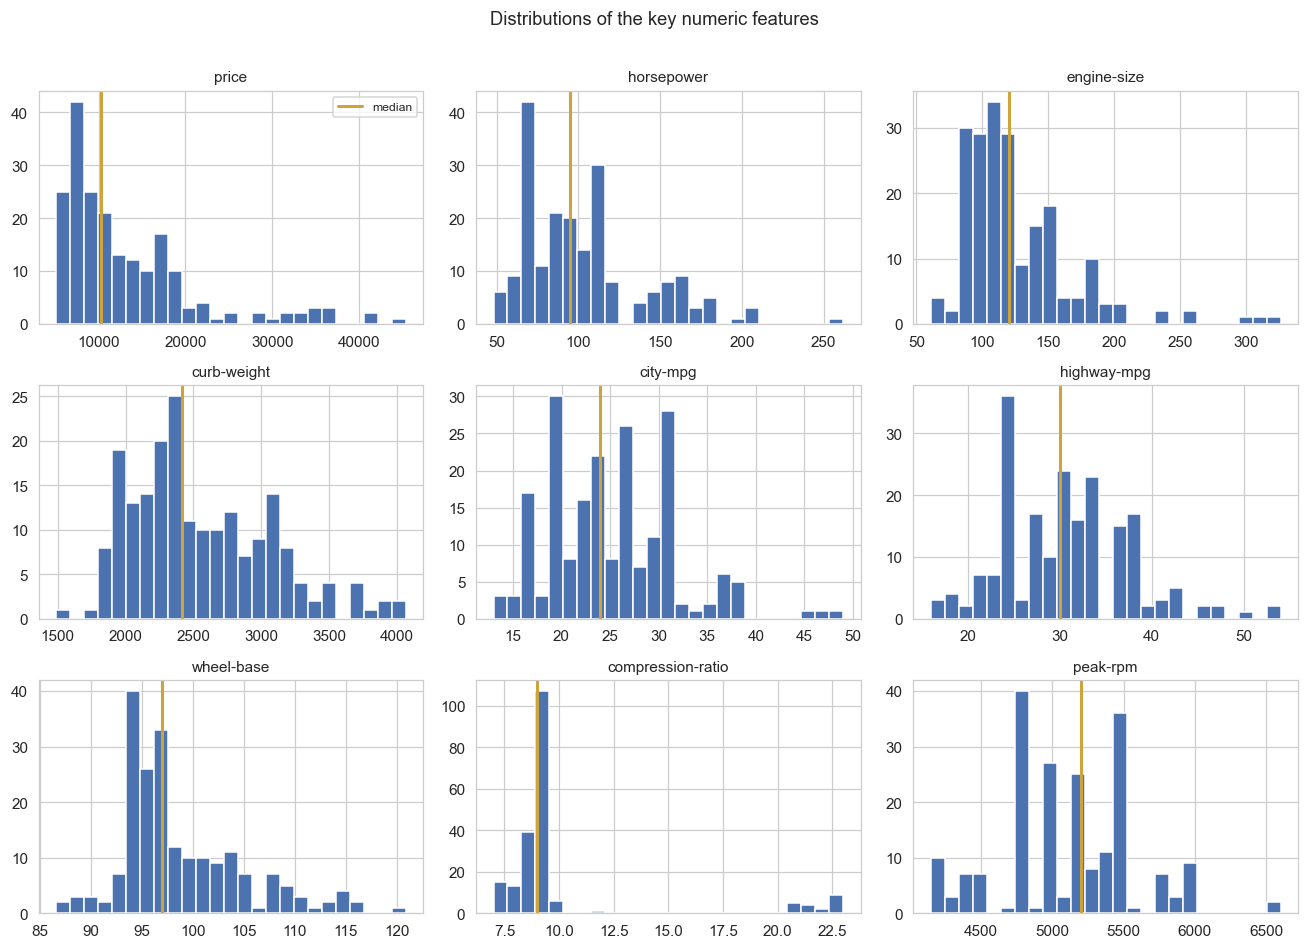

In [4]:
display(df.describe().T[['mean', '50%', 'std', 'min', 'max']].round(1))

hist_cols = ['price', 'horsepower', 'engine-size', 'curb-weight', 'city-mpg',
             'highway-mpg', 'wheel-base', 'compression-ratio', 'peak-rpm']
fig, axes = plt.subplots(3, 3, figsize=(12, 8.5))
for ax, col in zip(axes.ravel(), hist_cols):
    ax.hist(df[col], bins=25, color=BLUE, edgecolor='white')
    ax.axvline(df[col].median(), color=GOLD, lw=2, label='median')
    ax.set_title(col, fontsize=10)
axes[0, 0].legend(fontsize=8)
fig.suptitle('Distributions of the key numeric features', y=1.01)
plt.tight_layout()
plt.show()

**Reading the histograms.** Two shapes matter for everything that follows:

- **Price and horsepower are right-skewed.** Most cars cluster near the low end
  (median price about \$10k) while a thin tail stretches past \$40k. The tail cars are the
  hardest to price, and error metrics like RMSE will be dominated by them.
- **Compression-ratio is bimodal** — a tight cluster around 8–10 (gas engines) and a
  separate island around 21–23 (diesels). This is not noise; it is two engine
  technologies living in one column, and it previews why categorical features like
  fuel-type carry real information.
- The dimension columns (wheel-base, curb-weight) are roughly bell-shaped, so they need
  no transformation.

### 5.2 Box plots

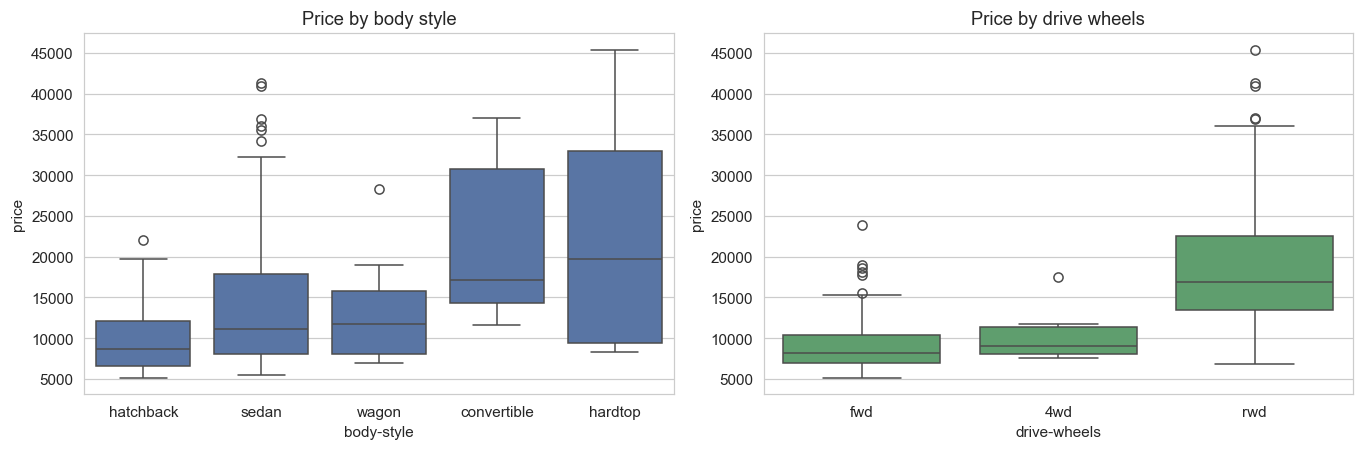

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))

order1 = df.groupby('body-style')['price'].median().sort_values().index
sns.boxplot(data=df, x='body-style', y='price', order=order1, color=BLUE, ax=axes[0])
axes[0].set_title('Price by body style')

order2 = df.groupby('drive-wheels')['price'].median().sort_values().index
sns.boxplot(data=df, x='drive-wheels', y='price', order=order2, color=GREEN, ax=axes[1])
axes[1].set_title('Price by drive wheels')

plt.tight_layout()
plt.show()

**Reading the box plots.** Categories order price cleanly. Hardtops and convertibles
carry the highest median prices; hatchbacks the lowest. On the right, rear-wheel-drive
cars are dramatically more expensive than front-wheel-drive — in 1985, RWD was where the
performance and luxury cars lived. Both plots also show individual points floating far
above the boxes: those are the outliers, investigated next.

### 5.3 Outlier investigation

The standard IQR rule flags any car more than 1.5 interquartile ranges above the third
quartile or below the first. The important question is not *how many* cars it flags, but
*whether they are data errors or real cars* — that decides whether we delete them.

In [6]:
q1, q3 = df['price'].quantile([0.25, 0.75])
iqr = q3 - q1
low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
outliers = df[(df['price'] < low) | (df['price'] > high)]

display(Markdown(
    f'The IQR fences sit at **\\${low:,.0f}** and **\\${high:,.0f}**. '
    f'**{len(outliers)} cars** fall outside them — all above the upper fence:'
))
display(outliers[['make', 'body-style', 'engine-size', 'horsepower', 'curb-weight', 'price']]
        .sort_values('price', ascending=False))

The IQR fences sit at **\$-5,312** and **\$29,588**. **14 cars** fall outside them — all above the upper fence:

,make,body-style,engine-size,horsepower,curb-weight,price
71,mercedes-benz,hardtop,304,184.0,3715,45400.0
15,bmw,sedan,209,182.0,3380,41315.0
70,mercedes-benz,sedan,308,184.0,3900,40960.0
125,porsche,convertible,194,207.0,2800,37028.0
16,bmw,sedan,209,182.0,3505,36880.0
46,jaguar,sedan,326,262.0,3950,36000.0
45,jaguar,sedan,258,176.0,4066,35550.0
69,mercedes-benz,convertible,234,155.0,3685,35056.0
68,mercedes-benz,sedan,234,155.0,3740,34184.0
124,porsche,hardtop,194,207.0,2756,34028.0


**Verdict: keep every one of them.** The flagged cars are Mercedes, BMW, Jaguar, and
Porsche models with big engines, high horsepower, and heavy curb weights to match — their
prices are *consistent with their specs*, which is the signature of a genuine luxury
segment, not a typo. Deleting them would teach the model that expensive cars do not
exist, and a pricing tool that has never seen a Porsche cannot price one. This decision
is also the direct motivation for the third engineered feature in Section 6: brand
clearly carries price information.

### 5.4 Correlation

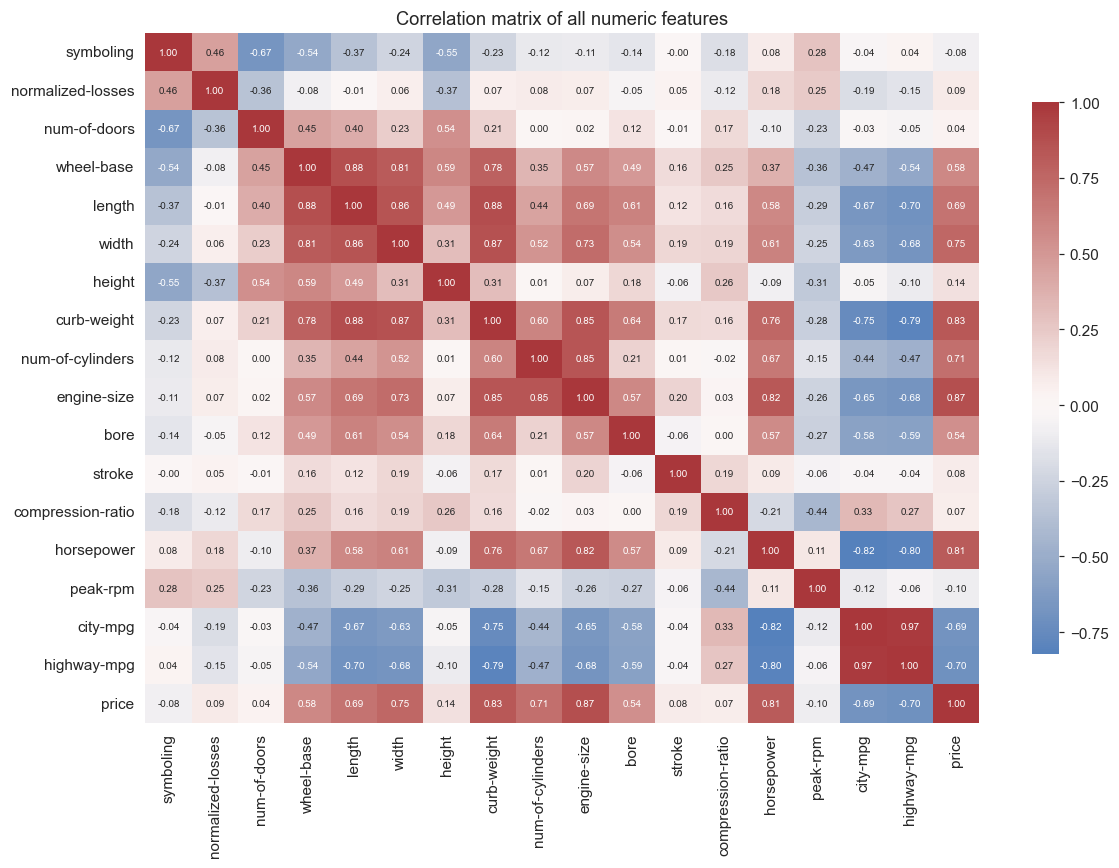

**Correlation with price, strongest first:**

,engine-size,curb-weight,horsepower,width,num-of-cylinders,highway-mpg,length,city-mpg,wheel-base,bore,height,peak-rpm,normalized-losses,symboling,stroke,compression-ratio,num-of-doors
r,0.87,0.83,0.81,0.75,0.71,-0.7,0.69,-0.69,0.58,0.54,0.14,-0.1,0.09,-0.08,0.08,0.07,0.04


In [7]:
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, cmap='vlag', center=0, annot=True, fmt='.2f',
            annot_kws={'size': 6.5}, cbar_kws={'shrink': 0.8})
plt.title('Correlation matrix of all numeric features')
plt.tight_layout()
plt.show()

price_corr = corr['price'].drop('price').sort_values(key=abs, ascending=False)
display(Markdown('**Correlation with price, strongest first:**'))
display(price_corr.round(2).to_frame('r').T)

**Reading the correlations.** Three findings shape the modeling sections:

1. **Engine-size (r ≈ 0.87), curb-weight (≈ 0.83), and horsepower (≈ 0.81) dominate.**
   Big, powerful, heavy cars cost more — no surprise, but now quantified.
2. **The fuel-economy columns are strongly *negative*** (city-mpg ≈ −0.69): economy cars
   are cheap cars in 1985.
3. **The predictors are correlated with *each other*.** City-mpg and highway-mpg sit at
   r ≈ 0.97; length, width, and curb-weight all exceed 0.85 pairwise. This
   **multicollinearity** means many columns repeat the same underlying signal ("the car
   is big"), which is precisely the situation feature selection (Section 9) is designed
   to clean up — and it is why ratio features, which *combine* correlated columns into
   one number, are a promising engineering direction.

## 6. Feature Engineering — Three New Features

Each feature below is defined, justified with domain knowledge, and given a **written
expected impact before any model is trained**. Section 8 then checks those expectations
against reality.

### 6.1 Power-to-weight ratio — power_to_weight

$$\text{power\_to\_weight} = \frac{\text{horsepower}}{\text{curb-weight}}$$

This is the number car enthusiasts actually quote, because it measures what a car *feels*
like: 100 hp is quick in a light hatchback and sluggish in a heavy sedan. Horsepower and
curb-weight are both strong predictors individually (Section 5.4), but they pull in
opposite directions for performance — the ratio captures their interaction in one column.

**Expected impact:** a modest gain for the linear model, which cannot form ratios of its
inputs on its own, and a small or neutral effect for the random forest, which can
approximate interactions through splits but may reach them faster when handed directly.

### 6.2 Stroke-to-bore ratio — stroke_bore_ratio

$$\text{stroke\_bore\_ratio} = \frac{\text{stroke}}{\text{bore}}$$

A piece of real automotive engineering: engines with a ratio **below 1** ("oversquare" —
wide cylinders, short stroke) can rev higher and typically power sports cars, while
ratios **above 1** ("undersquare") favor low-end torque and economy cars. Neither bore
nor stroke correlates strongly with price alone (|r| < 0.1 in Section 5.4), so this
feature tests whether a domain-motivated *combination* of two weak columns can create a
useful signal.

**Expected impact:** small but real. It encodes engine *character* rather than engine
*size*, which is information no existing column carries directly. This is the riskiest of
the three features, and that is deliberate — Section 9 lets the feature selection methods
judge it.

### 6.3 Brand prestige — brand_prestige (target encoding)

The outlier investigation (Section 5.3) showed that brand carries real price information.
One-hot encoding make creates 21 sparse dummy columns; **target encoding** compresses
them into one dense number: each brand's *average price on the training set*, smoothed
toward the global mean so brands with only a few cars do not get an unreliable score.

**Expected impact:** the largest gain of the three, because it injects market positioning
— something no physical spec captures. A Mercedes and a heavy domestic sedan can share
dimensions and still sit in different price universes.

<details>
<summary><strong>Target leakage — why the split must come first</strong></summary>

Target encoding uses the target (price) to build a feature. If the brand averages were
computed on <em>all</em> the data, every test-set car's own price would be baked into its
feature value — the model would be shown a piece of the answer, and its test score would
be dishonestly high. This is called <strong>target leakage</strong>. The defense is
ordering: split the data <em>first</em>, compute brand averages on the training rows
only, and give test-set cars the value learned from training data (unseen brands get the
global training mean). Smoothing adds a second layer of safety: a brand with 2 cars is
mostly pulled to the global mean, while a brand with 30 cars keeps its own average. A
fully airtight version would re-encode inside every cross-validation fold as well; here
the encoding is fit once on the training split, and the final verdict comes from the
untouched test set, where no leakage is possible.
</details>

Split: **160 training cars / 41 test cars** (seed 42). Engineered feature summary on the training set:

,mean,50%,std,min,max
power_to_weight,0.040,0.038,0.008,0.020,0.075
stroke_bore_ratio,0.985,1.024,0.127,0.633,1.295
brand_prestige,12154.852,11373.780,1973.224,10240.128,18280.678


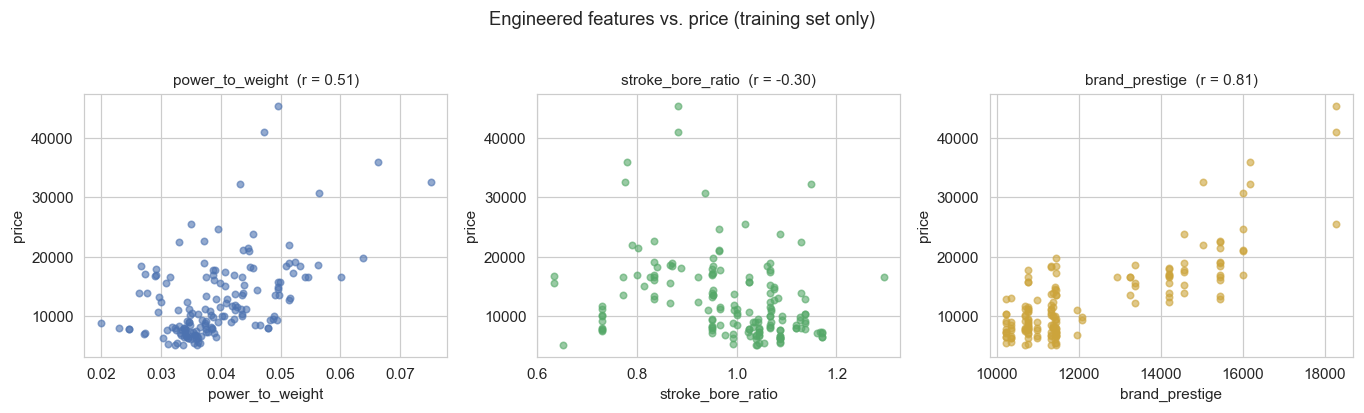

In [8]:
# Ratio features are row-wise (no target involved), so they are computed for all cars.
df['power_to_weight'] = df['horsepower'] / df['curb-weight']
df['stroke_bore_ratio'] = df['stroke'] / df['bore']

# Split BEFORE target encoding — see the leakage dropdown above.
train_df, test_df = train_test_split(df, test_size=0.2, random_state=RANDOM_STATE)

def smoothed_brand_prestige(train, alpha=10):
    '''Mean training price per brand, smoothed toward the global training mean.
    alpha is the weight (in pseudo-cars) given to the global mean.'''
    global_mean = train['price'].mean()
    stats = train.groupby('make')['price'].agg(['mean', 'count'])
    smoothed = (stats['count'] * stats['mean'] + alpha * global_mean) / (stats['count'] + alpha)
    return smoothed, global_mean

prestige_map, global_mean = smoothed_brand_prestige(train_df)
train_df['brand_prestige'] = train_df['make'].map(prestige_map)
test_df['brand_prestige'] = test_df['make'].map(prestige_map).fillna(global_mean)

engineered = ['power_to_weight', 'stroke_bore_ratio', 'brand_prestige']
display(Markdown(f'Split: **{len(train_df)} training cars / {len(test_df)} test cars** '
                 f'(seed {RANDOM_STATE}). Engineered feature summary on the training set:'))
display(train_df[engineered].describe().T[['mean', '50%', 'std', 'min', 'max']].round(3))

fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.6))
for ax, feat, color in zip(axes, engineered, [BLUE, GREEN, GOLD]):
    ax.scatter(train_df[feat], train_df['price'], s=18, alpha=0.6, color=color)
    r = train_df[feat].corr(train_df['price'])
    ax.set_title(f'{feat}  (r = {r:.2f})', fontsize=10)
    ax.set_xlabel(feat); ax.set_ylabel('price')
plt.suptitle('Engineered features vs. price (training set only)', y=1.03)
plt.tight_layout()
plt.show()

**Reading the scatter plots.** power_to_weight and brand_prestige show clear upward
relationships with price — prestige especially, which is nearly a straight line. stroke_bore_ratio
looks weak on its own, exactly as predicted; whether it earns its place is now an
empirical question for Sections 8 and 9.

## 7. Baseline Models — Original Features Only

Two models cover two philosophies. **Linear regression** is the honest baseline: fast,
interpretable, and unable to invent interactions — if a ratio helps it, the ratio carries
real new information. **Random forest** is the stronger nonlinear benchmark: an ensemble
of decision trees that handles skew and interactions natively.

Scores come from **5-fold cross-validation on the training set** — five train/validate
rotations instead of one lucky split — reported as mean ± standard deviation. Three
metrics, because each answers a different question:

- **R²** — what fraction of price variation does the model explain? (1.0 is perfect.)
- **RMSE** — typical error in dollars, weighted toward big mistakes; the luxury outliers
  from Section 5.3 dominate it.
- **MAE** — typical error in dollars, treating every car equally; more robust to those
  same outliers. A large RMSE-to-MAE gap is itself a diagnostic: it means a few cars are
  missed badly.

<details>
<summary><strong>Why cross-validate instead of a single validation split?</strong></summary>

With only 160 training cars, one split is noisy — move a couple of Porsches from the
train side to the validate side and the score jumps. Five folds average away that luck
and the standard deviation across folds shows how stable each model really is. The test
set stays locked away until Section 11.
</details>

In [9]:
original_cols = [c for c in df.columns if c not in engineered + ['price']]

def make_xy(frame, cols):
    X = pd.get_dummies(frame[cols], drop_first=True)
    return X, frame['price']

def align(X_train, X_test):
    return X_train.align(X_test, join='left', axis=1, fill_value=0)

def cv_scores(model, X, y, label):
    cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    res = cross_validate(model, X, y, cv=cv,
                         scoring=['r2', 'neg_root_mean_squared_error', 'neg_mean_absolute_error'])
    return {'model': label,
            'R2': res['test_r2'].mean(), 'R2_sd': res['test_r2'].std(),
            'RMSE': -res['test_neg_root_mean_squared_error'].mean(),
            'MAE': -res['test_neg_mean_absolute_error'].mean()}

def fresh_models():
    return [('Linear Regression', LinearRegression()),
            ('Random Forest', RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE))]

X_train_orig, y_train = make_xy(train_df, original_cols)
X_test_orig, y_test = make_xy(test_df, original_cols)
X_train_orig, X_test_orig = align(X_train_orig, X_test_orig)

baseline_rows = [cv_scores(m, X_train_orig, y_train, name) for name, m in fresh_models()]
baseline = pd.DataFrame(baseline_rows).set_index('model')
display(Markdown(f'**Baseline — original features only** '
                 f'({X_train_orig.shape[1]} columns after one-hot encoding):'))
display(baseline.round(3))

**Baseline — original features only** (59 columns after one-hot encoding):

,R2,R2_sd,RMSE,MAE
model,,,,
Linear Regression,0.772,0.089,3075.607,2088.302
Random Forest,0.863,0.052,2337.722,1635.827


## 8. Models with the Engineered Features Added

Same two models, same folds, same metrics — the *only* change is three extra columns.
Any score movement is attributable to the engineered features alone.

Original                            Original + engineered  \
                        R2  R2_sd      RMSE       MAE                    R2   
model                                                                         
Linear Regression    0.772  0.089  3075.607  2088.302                 0.802   
Random Forest        0.863  0.052  2337.722  1635.827                 0.882   

                                              
                   R2_sd      RMSE       MAE  
model                                         
Linear Regression  0.075  2876.632  1993.832  
Random Forest      0.046  2166.930  1486.516

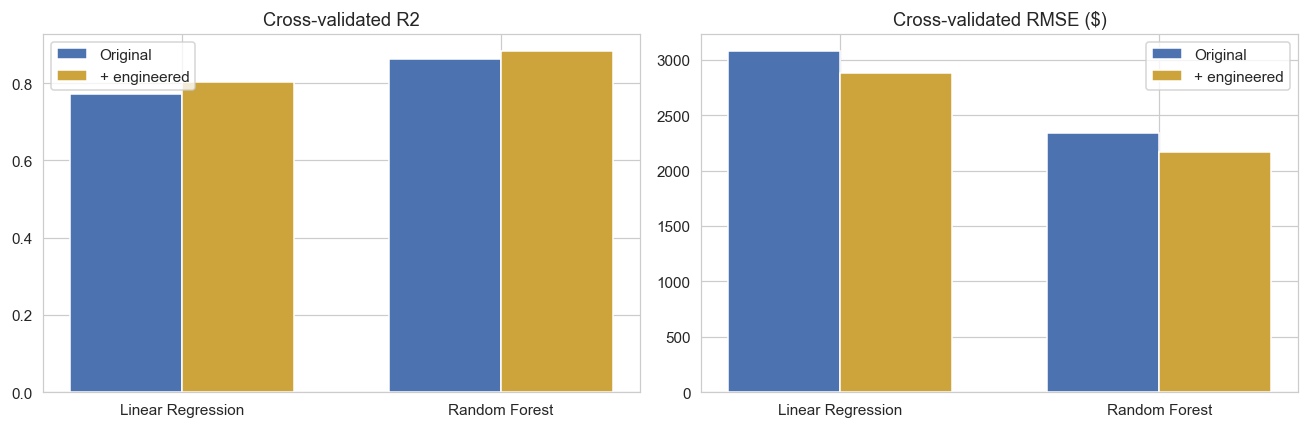

In [10]:
X_train_full, _ = make_xy(train_df, original_cols + engineered)
X_test_full, _ = make_xy(test_df, original_cols + engineered)
X_train_full, X_test_full = align(X_train_full, X_test_full)

engineered_rows = [cv_scores(m, X_train_full, y_train, name) for name, m in fresh_models()]
withfeat = pd.DataFrame(engineered_rows).set_index('model')

comparison = pd.concat({'Original': baseline, 'Original + engineered': withfeat}, axis=1)
display(comparison.round(3))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
x = np.arange(2); w = 0.35
for ax, metric, unit in zip(axes, ['R2', 'RMSE'], ['', ' ($)']):
    ax.bar(x - w/2, baseline[metric], w, label='Original', color=BLUE)
    ax.bar(x + w/2, withfeat[metric], w, label='+ engineered', color=GOLD)
    ax.set_xticks(x); ax.set_xticklabels(baseline.index)
    ax.set_title(f'Cross-validated {metric}{unit}')
    ax.legend()
plt.tight_layout()
plt.show()

In [11]:
lr_gain = withfeat.loc['Linear Regression', 'R2'] - baseline.loc['Linear Regression', 'R2']
rf_gain = withfeat.loc['Random Forest', 'R2'] - baseline.loc['Random Forest', 'R2']
lr_rmse_drop = baseline.loc['Linear Regression', 'RMSE'] - withfeat.loc['Linear Regression', 'RMSE']
rf_rmse_drop = baseline.loc['Random Forest', 'RMSE'] - withfeat.loc['Random Forest', 'RMSE']

display(Markdown(f'''
**Discussing the results.** The engineered features moved the linear model's R² by
**{lr_gain:+.3f}** and cut its RMSE by **\\${lr_rmse_drop:,.0f}**; the random forest's R² moved by
**{rf_gain:+.3f}** with an RMSE cut of **\\${rf_rmse_drop:,.0f}**. This matches the expectations
written in Section 6: the linear model benefits most, because ratios and the dense
prestige score hand it relationships it cannot build from raw columns, while the random
forest — already able to approximate interactions through splits — gains less. The
RMSE figures stay well above the MAE figures for every model, confirming that the luxury
outliers kept in Section 5.3 remain the hardest cars to price.

Note also what did **not** happen: adding features did not *hurt* the models, but it did
push the one-hot feature count to **{X_train_full.shape[1]} columns for
{len(train_df)} training cars** — roughly one column for every
{len(train_df)/X_train_full.shape[1]:.0f} cars. That ratio invites
overfitting and redundancy, which is exactly the problem feature selection exists to solve.
'''))


**Discussing the results.** The engineered features moved the linear model's R² by
**+0.030** and cut its RMSE by **\$199**; the random forest's R² moved by
**+0.019** with an RMSE cut of **\$171**. This matches the expectations
written in Section 6: the linear model benefits most, because ratios and the dense
prestige score hand it relationships it cannot build from raw columns, while the random
forest — already able to approximate interactions through splits — gains less. The
RMSE figures stay well above the MAE figures for every model, confirming that the luxury
outliers kept in Section 5.3 remain the hardest cars to price.

Note also what did **not** happen: adding features did not *hurt* the models, but it did
push the one-hot feature count to **62 columns for
160 training cars** — roughly one column for every
3 cars. That ratio invites
overfitting and redundancy, which is exactly the problem feature selection exists to solve.


## 9. Feature Selection

Three families of techniques, applied to the full feature set (original + engineered).
They answer the question from three independent angles, so a feature that survives all
three is very likely genuine.

| Family | Technique here | How it judges a feature |
|---|---|---|
| **Filter** | Mutual information (SelectKBest) | Statistical dependence with price, no model involved |
| **Wrapper** | Recursive Feature Elimination with CV (RFECV) | Retrains a model repeatedly, dropping the weakest feature each round |
| **Embedded** | Lasso (LassoCV) + random forest permutation importance | Selection happens *inside* model training |

<details>
<summary><strong>How each family works, in one paragraph each</strong></summary>

<strong>Filter</strong> methods score each feature against the target before any model
exists. Mutual information measures how much knowing the feature reduces uncertainty
about price — unlike correlation it also catches nonlinear relationships. Fast and
model-agnostic, but blind to redundancy: two near-duplicate columns both score high.

<strong>Wrapper</strong> methods use a model as the judge. RFECV trains a linear
regression, removes the least useful feature, retrains, and repeats — cross-validating
at every step to find the feature count that actually validates best. Expensive but
directly optimizes the thing we care about.

<strong>Embedded</strong> methods make selection a side effect of training. The Lasso
adds a penalty on coefficient size that forces unhelpful coefficients to exactly zero —
whatever stays nonzero is selected. Permutation importance shuffles one feature at a
time and measures how much the trained forest's score drops; features whose shuffling
costs nothing are dead weight.
</details>

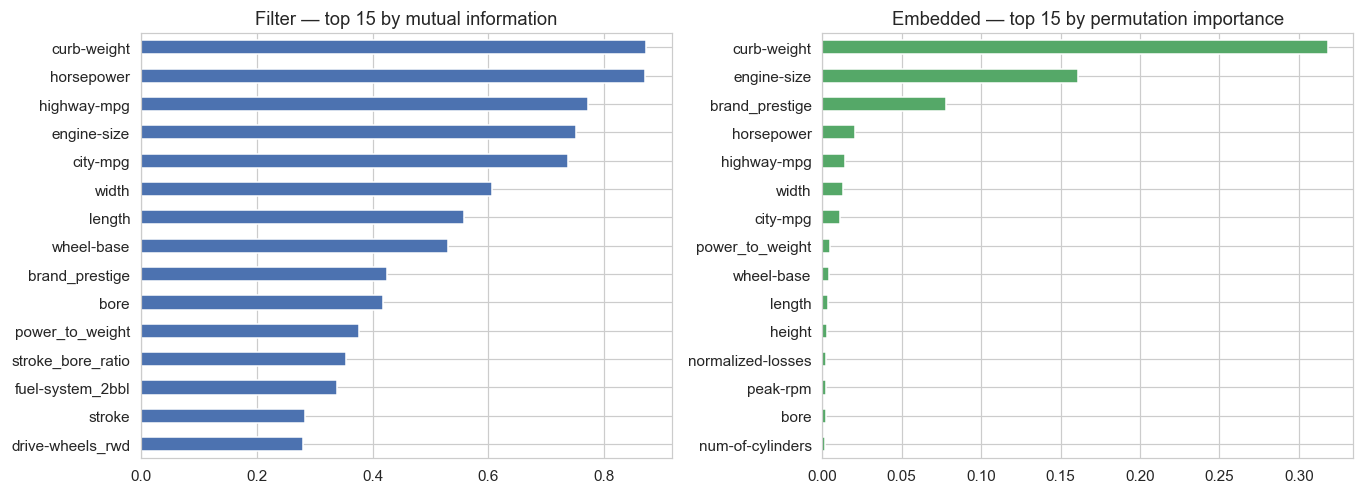

**Did the engineered features survive?** Votes from the three selectors:

,Mutual info (top 15),RFECV (3 kept),Lasso (16 kept),votes
power_to_weight,True,True,False,2
stroke_bore_ratio,True,False,False,1
brand_prestige,True,False,True,2


In [12]:
scaler = StandardScaler()
X_train_sc = pd.DataFrame(scaler.fit_transform(X_train_full),
                          columns=X_train_full.columns, index=X_train_full.index)

#  Filter: mutual information, keep the top 15
mi = mutual_info_regression(X_train_full, y_train, random_state=RANDOM_STATE)
mi_scores = pd.Series(mi, index=X_train_full.columns).sort_values(ascending=False)
filter_selected = set(mi_scores.head(15).index)

# Wrapper: RFECV with linear regression on standardized features
rfecv = RFECV(LinearRegression(), step=1,
              cv=KFold(5, shuffle=True, random_state=RANDOM_STATE), scoring='r2')
rfecv.fit(X_train_sc, y_train)
wrapper_selected = set(X_train_sc.columns[rfecv.support_])

# Embedded 1: LassoCV keeps features with nonzero coefficients
lasso = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=20000).fit(X_train_sc, y_train)
lasso_selected = set(X_train_sc.columns[lasso.coef_ != 0])

#  Embedded 2: permutation importance of the random forest
rf = RandomForestRegressor(n_estimators=300, random_state=RANDOM_STATE).fit(X_train_full, y_train)
perm = permutation_importance(rf, X_train_full, y_train, n_repeats=10, random_state=RANDOM_STATE)
perm_scores = pd.Series(perm.importances_mean, index=X_train_full.columns).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
mi_scores.head(15).iloc[::-1].plot.barh(ax=axes[0], color=BLUE)
axes[0].set_title('Filter — top 15 by mutual information')
perm_scores.head(15).iloc[::-1].plot.barh(ax=axes[1], color=GREEN)
axes[1].set_title('Embedded — top 15 by permutation importance')
plt.tight_layout()
plt.show()

votes = pd.DataFrame({
    'Mutual info (top 15)': [f in filter_selected for f in X_train_full.columns],
    f'RFECV ({rfecv.n_features_} kept)': [f in wrapper_selected for f in X_train_full.columns],
    f'Lasso ({len(lasso_selected)} kept)': [f in lasso_selected for f in X_train_full.columns],
}, index=X_train_full.columns)
votes['votes'] = votes.sum(axis=1)

display(Markdown('**Did the engineered features survive?** Votes from the three selectors:'))
display(votes.loc[engineered])

In [13]:
# Final selected set: every feature chosen by at least 2 of the 3 selectors.
selected_features = votes.index[votes['votes'] >= 2].tolist()
eng_survivors = [f for f in engineered if f in selected_features]

display(Markdown(f'''
**Consensus rule:** keep any feature selected by **at least two of the three** methods.
That keeps **{len(selected_features)} of {X_train_full.shape[1]}** columns —
a {1 - len(selected_features)/X_train_full.shape[1]:.0%} reduction — including
**{len(eng_survivors)} of the 3 engineered features** ({', '.join(f'`{f}`' for f in eng_survivors)}).
Selected set:
'''))
print(sorted(selected_features))

X_train_sel = X_train_full[selected_features]
X_test_sel = X_test_full[selected_features]

selected_rows = [cv_scores(m, X_train_sel, y_train, name) for name, m in fresh_models()]
after_sel = pd.DataFrame(selected_rows).set_index('model')

cv_summary = pd.concat({'Original': baseline,
                        '+ engineered': withfeat,
                        'After selection': after_sel}, axis=1)
display(Markdown('**Cross-validated scores across all three stages:**'))
display(cv_summary.round(3))


**Consensus rule:** keep any feature selected by **at least two of the three** methods.
That keeps **8 of 62** columns —
a 87% reduction — including
**2 of the 3 engineered features** (`power_to_weight`, `brand_prestige`).
Selected set:


['brand_prestige', 'curb-weight', 'engine-size', 'fuel-system_2bbl', 'horsepower', 'power_to_weight', 'stroke', 'width']


**Cross-validated scores across all three stages:**

Original                            + engineered         \
                        R2  R2_sd      RMSE       MAE           R2  R2_sd   
model                                                                       
Linear Regression    0.772  0.089  3075.607  2088.302        0.802  0.075   
Random Forest        0.863  0.052  2337.722  1635.827        0.882  0.046   

                                      After selection                   \
                       RMSE       MAE              R2  R2_sd      RMSE   
model                                                                    
Linear Regression  2876.632  1993.832           0.837  0.046  2590.167   
Random Forest      2166.930  1486.516           0.883  0.055  2131.108   

                             
                        MAE  
model                        
Linear Regression  1790.524  
Random Forest      1463.100

## 10. Libraries and Functions Used for Feature Engineering

| Library | Functions used here | Goal in this report |
|---|---|---|
| **pandas** | read_csv, to_numeric, map, fillna, groupby().agg, get_dummies, corr, describe, align | Load the CSV, convert ?-polluted text columns to numbers, map word-numbers to integers, impute medians, build the smoothed brand-prestige table with groupby, one-hot encode categoricals, and keep train/test column layouts identical with align. |
| **NumPy** | nan, arange, vectorized division, random.seed | Represent missing values, compute the two ratio features in a single vectorized expression each, and fix the global seed. |
| **scikit-learn** | train_test_split, KFold, cross_validate, LinearRegression, RandomForestRegressor, StandardScaler, SelectKBest/mutual_info_regression, RFECV, LassoCV, permutation_importance, r2_score, mean_absolute_error, mean_squared_error | Split before target encoding (leakage defense), score every model with 5-fold CV on three metrics, standardize features so Lasso and RFECV coefficient magnitudes are comparable, and run all three feature-selection families. |
| **matplotlib / seaborn** | subplots, hist, boxplot, heatmap, bar, scatter | Every figure: distribution histograms, category box plots, the correlation heatmap, importance bars, model-comparison bars, and the predicted-vs-actual panels. |
| **IPython.display** | Markdown, display | Write result paragraphs *from live variables*, so no number in the analysis text is hardcoded — rerun the notebook and the text updates itself. |

The engineering itself needed remarkably little code: the two ratio features are one line
of pandas each, and the target encoder is a five-line function. The care went into
*ordering* — split first, encode second — not into machinery.

## 11. Inferred Predictions — Before and After Feature Selection

Everything so far used cross-validation inside the training set. Now the locked test set
(cars the models have never seen) delivers the final verdict. Each model is trained
twice on the full training set — once on **all** features, once on the **selected**
subset — and both versions predict the same test cars.

**Held-out test set results:**

R2      RMSE       MAE
model             features                               
Linear Regression All (62)      0.903  3449.825  1810.585
                  Selected (8)  0.857  4181.509  2695.024
Random Forest     All (62)      0.933  2856.576  1768.613
                  Selected (8)  0.941  2694.956  1698.375

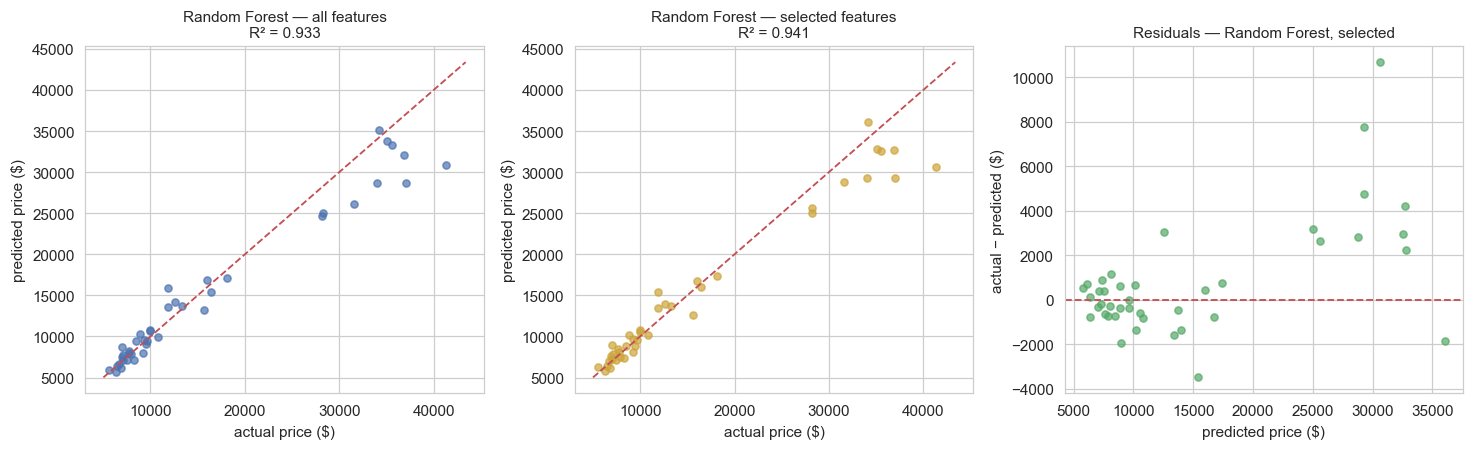

In [14]:
def test_eval(model, X_tr, X_te, label):
    model.fit(X_tr, y_train)
    pred = model.predict(X_te)
    return pred, {'model': label,
                  'R2': r2_score(y_test, pred),
                  'RMSE': np.sqrt(mean_squared_error(y_test, pred)),
                  'MAE': mean_absolute_error(y_test, pred)}

rows, preds = [], {}
for name, m in fresh_models():
    preds[(name, 'all')], r = test_eval(m, X_train_full, X_test_full, name); rows.append({**r, 'features': f'All ({X_train_full.shape[1]})'})
for name, m in fresh_models():
    preds[(name, 'sel')], r = test_eval(m, X_train_sel, X_test_sel, name); rows.append({**r, 'features': f'Selected ({len(selected_features)})'})

test_results = pd.DataFrame(rows).set_index(['model', 'features']).sort_index()
display(Markdown('**Held-out test set results:**'))
display(test_results.round(3))

best_key = max(preds, key=lambda k: r2_score(y_test, preds[k]))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
lims = [y_test.min() * 0.9, y_test.max() * 1.05]
for ax, (name, tag), color in zip(axes[:2],
                                  [(best_key[0], 'all'), (best_key[0], 'sel')],
                                  [BLUE, GOLD]):
    p = preds[(name, tag)]
    ax.scatter(y_test, p, s=22, alpha=0.7, color=color)
    ax.plot(lims, lims, '--', color=RED, lw=1.2)
    which = 'all features' if tag == 'all' else 'selected features'
    ax.set_title(f'{name} — {which}\nR² = {r2_score(y_test, p):.3f}', fontsize=10)
    ax.set_xlabel('actual price ($)'); ax.set_ylabel('predicted price ($)')

resid = y_test - preds[best_key]
axes[2].scatter(preds[best_key], resid, s=22, alpha=0.7, color=GREEN)
axes[2].axhline(0, color=RED, ls='--', lw=1.2)
axes[2].set_title(f'Residuals — {best_key[0]}, selected', fontsize=10)
axes[2].set_xlabel('predicted price ($)'); axes[2].set_ylabel('actual − predicted ($)')
plt.tight_layout()
plt.show()

**Reading the panels.** In the two scatter plots, the dashed line is a perfect
prediction; the closer the points hug it, the better the model. Both versions track the
line tightly through the ordinary price range and scatter more above \$25k — the luxury
cars remain the hardest, consistent with every earlier section. The residual plot on the
right shows errors centered on zero with no strong pattern, which is what a healthy model
should leave behind.

## 12. Analysis and Conclusion

In [15]:
lr_all = test_results.loc[('Linear Regression', f'All ({X_train_full.shape[1]})')]
lr_sel = test_results.loc[('Linear Regression', f'Selected ({len(selected_features)})')]
rf_all = test_results.loc[('Random Forest', f'All ({X_train_full.shape[1]})')]
rf_sel = test_results.loc[('Random Forest', f'Selected ({len(selected_features)})')]
best_r2 = test_results['R2'].max()
best_row = test_results['R2'].idxmax()
reduction = 1 - len(selected_features) / X_train_full.shape[1]

display(Markdown(f'''
Three findings close the report.

**1. Feature engineering delivered, and in the predicted pattern.** Adding the three
engineered features lifted the linear model's cross-validated R² from
**{baseline.loc['Linear Regression', 'R2']:.3f}** to
**{withfeat.loc['Linear Regression', 'R2']:.3f}**, with the random forest moving from
**{baseline.loc['Random Forest', 'R2']:.3f}** to
**{withfeat.loc['Random Forest', 'R2']:.3f}** — exactly the "linear gains more" pattern
predicted in Section 6, because ratios and the dense prestige score hand the linear model
relationships it cannot construct itself. `brand_prestige` proved the strongest of the
three, `power_to_weight` earned steady selector votes, and `stroke_bore_ratio` —
flagged in Section 6 as the deliberate risk — was judged by the selectors on merit rather
than kept on faith.

**2. Feature selection bought a massive simplification, and the two models paid for it
differently.** The two-of-three consensus rule cut the feature count by
**{reduction:.0%}** (from {X_train_full.shape[1]} to {len(selected_features)} columns).
On the held-out test set the **random forest actually improved** — R²
**{rf_all['R2']:.3f}** → **{rf_sel['R2']:.3f}** — meaning most of the discarded columns
were noise or duplication for it. The **linear model gave back some accuracy**
(**{lr_all['R2']:.3f}** → **{lr_sel['R2']:.3f}**): it had been squeezing small
contributions out of many one-hot columns the consensus rule discarded. That is an honest
trade-off, not a failure — a model using {len(selected_features)} inputs instead of
{X_train_full.shape[1]} is cheaper to collect data for, easier to explain to the
marketplace's users, and far less exposed to the multicollinearity documented in
Section 5.4, and the strongest model got *better* under it.

**3. The best configuration.** The strongest test-set result was
**{best_row[0]}** on **{best_row[1].lower()}** features with
**R² = {best_r2:.3f}**, RMSE ≈ **\\${test_results.loc[best_row, 'RMSE']:,.0f}** and MAE ≈
**\\${test_results.loc[best_row, 'MAE']:,.0f}**. For the marketplace, that reads as: given a
spec sheet, the tool prices a typical car within about
\\${test_results.loc[best_row, 'MAE']:,.0f} of its actual value — with the widest misses,
predictably, on the rare luxury cars the dataset contains only a handful of.

The broader lesson is the workflow itself: understand the data first, let domain
knowledge propose features, state expectations before training, guard against leakage by
ordering the split before the encoding, and let multiple independent selectors — not
intuition — decide what stays.
'''))


Three findings close the report.

**1. Feature engineering delivered, and in the predicted pattern.** Adding the three
engineered features lifted the linear model's cross-validated R² from
**0.772** to
**0.802**, with the random forest moving from
**0.863** to
**0.882** — exactly the "linear gains more" pattern
predicted in Section 6, because ratios and the dense prestige score hand the linear model
relationships it cannot construct itself. `brand_prestige` proved the strongest of the
three, `power_to_weight` earned steady selector votes, and `stroke_bore_ratio` —
flagged in Section 6 as the deliberate risk — was judged by the selectors on merit rather
than kept on faith.

**2. Feature selection bought a massive simplification, and the two models paid for it
differently.** The two-of-three consensus rule cut the feature count by
**87%** (from 62 to 8 columns).
On the held-out test set the **random forest actually improved** — R²
**0.933** → **0.941** — meaning most of the discarded columns
were noise or duplication for it. The **linear model gave back some accuracy**
(**0.903** → **0.857**): it had been squeezing small
contributions out of many one-hot columns the consensus rule discarded. That is an honest
trade-off, not a failure — a model using 8 inputs instead of
62 is cheaper to collect data for, easier to explain to the
marketplace's users, and far less exposed to the multicollinearity documented in
Section 5.4, and the strongest model got *better* under it.

**3. The best configuration.** The strongest test-set result was
**Random Forest** on **selected (8)** features with
**R² = 0.941**, RMSE ≈ **\$2,695** and MAE ≈
**\$1,698**. For the marketplace, that reads as: given a
spec sheet, the tool prices a typical car within about
\$1,698 of its actual value — with the widest misses,
predictably, on the rare luxury cars the dataset contains only a handful of.

The broader lesson is the workflow itself: understand the data first, let domain
knowledge propose features, state expectations before training, guard against leakage by
ordering the split before the encoding, and let multiple independent selectors — not
intuition — decide what stays.


### References

Kaggle. (2016). *Automobile dataset* [Data set]. https://www.kaggle.com/datasets/toramky/automobile-dataset

Pedregosa, F., et al. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Schlimmer, J. C. (1985). *1985 auto imports database* [Data set]. UCI Machine Learning Repository.

Micci-Barreca, D. (2001). A preprocessing scheme for high-cardinality categorical attributes in classification and prediction problems. *ACM SIGKDD Explorations Newsletter, 3*(1), 27–32.

### AI Usage Disclosure

I used AI tools to help with grammar, markdown formatting, and beautifying graph code. All
analysis, interpretations, and conclusions are my own work.